# Apple (AAPL) Stock - Exploratory Data Analysis

## Objective
Understand stock behavior, trends, and relationships between variables.

## Dataset Files Used
- aapl_stock_prices
- aapl_technical_indicators
- aapl_financials (later)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')

## Load data

In [2]:
stock = pd.read_csv('../data/raw/aapl_stock_prices.csv')
stock.head()

,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600


## Basic Info

In [3]:
stock.shape
stock.info()
stock.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11407 entries, 0 to 11406
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11407 non-null  object 
 1   Open    11407 non-null  float64
 2   High    11407 non-null  float64
 3   Low     11407 non-null  float64
 4   Close   11407 non-null  float64
 5   Volume  11407 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 534.8+ KB


,Open,High,Low,Close,Volume
count,11407.000000,11407.000000,11407.000000,11407.000000,1.140700e+04
mean,28.984080,29.297458,28.688258,29.005178,3.085393e+08
std,59.703957,60.342481,59.111794,59.752525,3.331123e+08
min,0.038037,0.038037,0.037609,0.037609,0.000000e+00
25%,0.246723,0.253475,0.241507,0.247030,1.054778e+08
50%,0.491719,0.501578,0.482554,0.492607,1.972992e+08
75%,21.854912,22.089203,21.674885,21.864207,3.887842e+08
max,285.932471,288.350192,283.035157,285.922455,7.421641e+09


## Convert Date

In [4]:
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock.sort_values('Date')
stock.set_index('Date', inplace=True)

## Missing Values

In [5]:
stock.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

## Price Trend

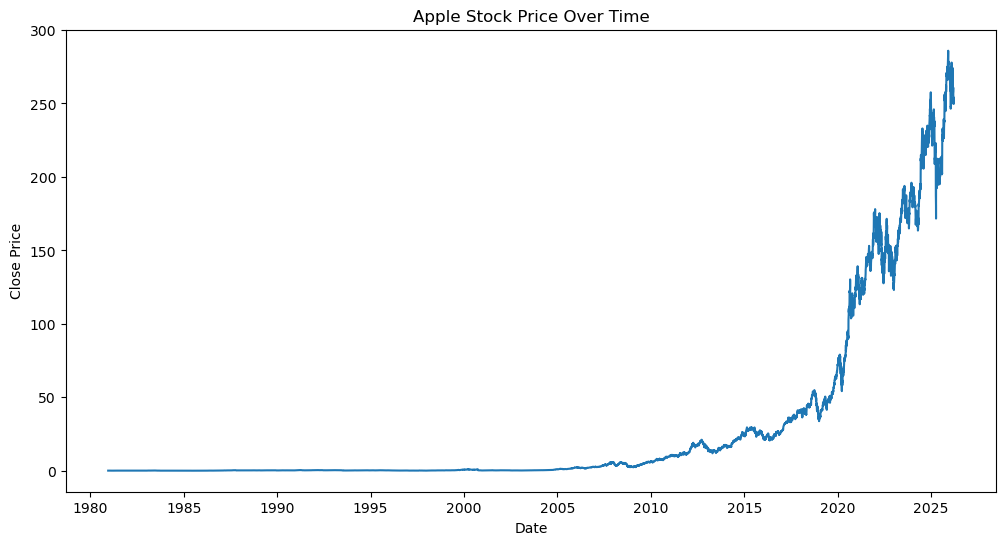

In [6]:
plt.figure(figsize=(12,6))
plt.plot(stock['Close'])
plt.title('Apple Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

## Volume Analysis

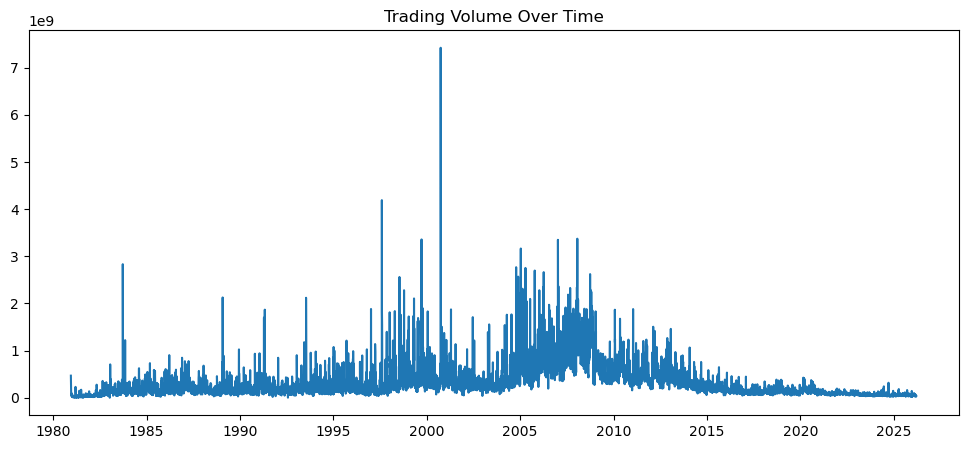

In [7]:
plt.figure(figsize=(12,5))
plt.plot(stock['Volume'])
plt.title('Trading Volume Over Time')
plt.show()

## Distribution

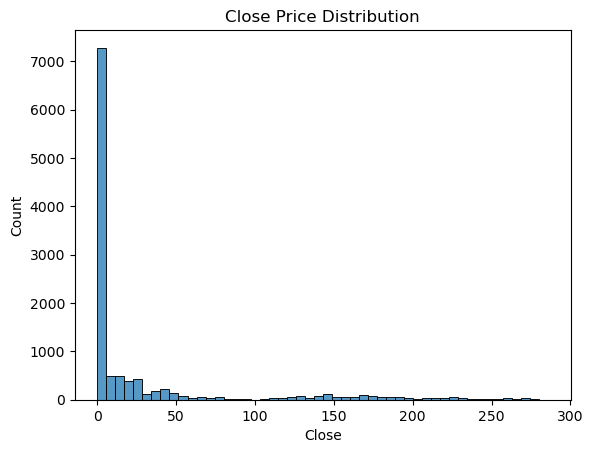

In [17]:
sns.histplot(stock['Close'], bins=50)
plt.title('Close Price Distribution')
plt.show()

## Correlation

In [12]:
stock[['Open','High','Low','Close','Volume']].corr()

,Open,High,Low,Close,Volume
Open,1.000000,0.999937,0.999940,0.999873,-0.287284
High,0.999937,1.000000,0.999918,0.999943,-0.287010
Low,0.999940,0.999918,1.000000,0.999942,-0.287684
Close,0.999873,0.999943,0.999942,1.000000,-0.287359
Volume,-0.287284,-0.287010,-0.287684,-0.287359,1.000000


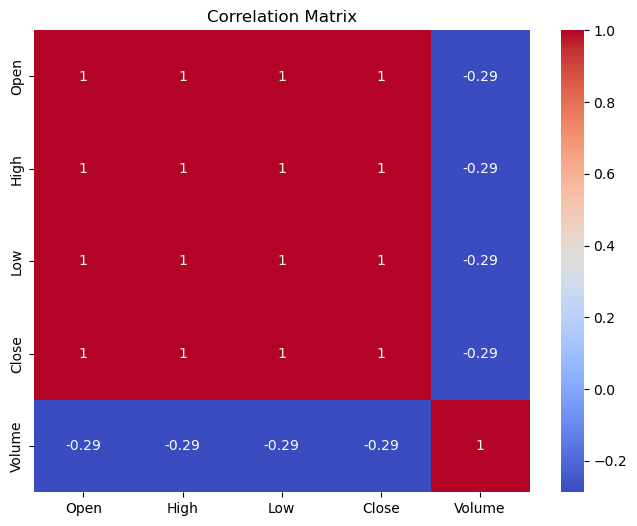

In [13]:
corr = stock[['Open','High','Low','Close','Volume']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Returns

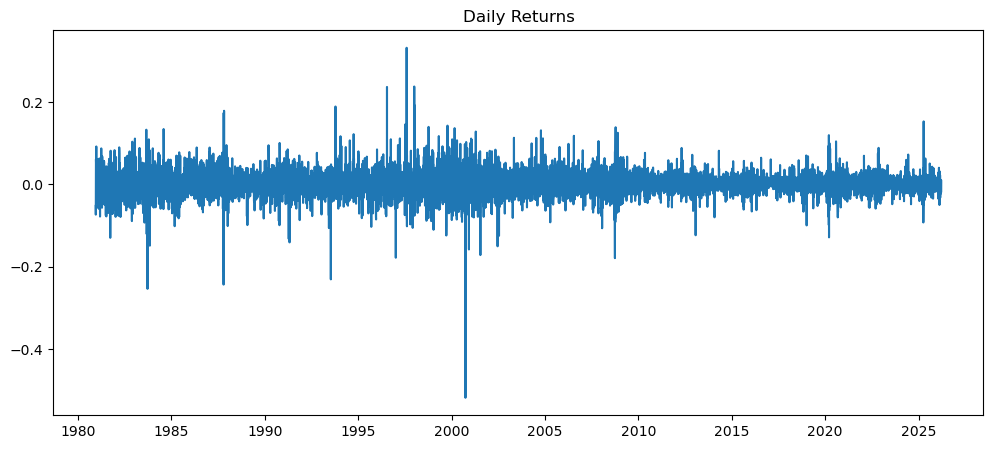

In [10]:
stock['Return'] = stock['Close'].pct_change()

plt.figure(figsize=(12,5))
plt.plot(stock['Return'])
plt.title('Daily Returns')
plt.show()

## Rolling Average

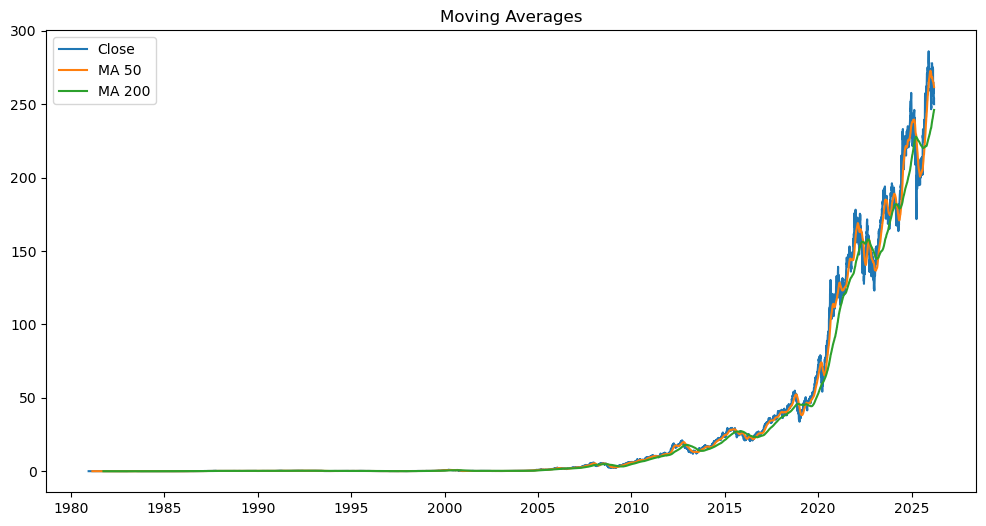

In [11]:
stock['MA_50'] = stock['Close'].rolling(50).mean()
stock['MA_200'] = stock['Close'].rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(stock['Close'], label='Close')
plt.plot(stock['MA_50'], label='MA 50')
plt.plot(stock['MA_200'], label='MA 200')

plt.legend()
plt.title('Moving Averages')
plt.show()

## Key Insights

### 1. Long-Term Trend
- Apple stock shows a strong long-term upward trend.
- Growth was relatively slow before 2005, followed by steady growth.
- Significant acceleration is observed after 2010, with aggressive growth after 2020.

---

### 2. Price Behavior
- Stock prices exhibit exponential growth over time.
- Early historical values appear close to zero due to scale differences.
- This indicates that raw price is not stationary and may not be suitable directly for modeling.

---

### 3. Volatility
- The stock demonstrates periods of high volatility, especially in recent years.
- Sharp spikes and drops indicate sensitivity to market events and external factors.

---

### 4. Trading Volume
- Trading volume is highly inconsistent over time.
- Large spikes in volume suggest major market events or strong investor activity.
- No stable pattern is observed in volume behavior.

---

### 5. Correlation Analysis
- Open, High, Low, and Close prices are highly correlated (≈ 0.99).
- This indicates redundancy among price features.
- Volume shows weaker correlation with price variables, suggesting different behavior.

---

### 6. Returns Behavior
- Returns (percentage change in price) fluctuate around zero.
- High spikes in returns indicate strong short-term volatility.
- Returns provide a more stable and meaningful representation for modeling compared to raw prices.

---

### 7. Data Characteristics
- The dataset is non-stationary due to strong upward trend over time.
- Transformations such as returns or log scaling are required for effective modeling.

---

## Conclusion
- Apple stock exhibits strong growth with increasing volatility.
- Raw price data alone is not sufficient for predictive modeling.
- Feature engineering and transformation will be essential in the next step.